In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **Part A — Data preparation **


1. Load both datasets and document:
number of rows/columns
# missing values / duplicates


In [5]:
# here i have uploaded both dataset and print row and columm both dataset

fear_greed=pd.read_csv('fear_greed_index.csv')
historical=pd.read_csv('historical_data.csv')

print("Fear/Greed shape:", fear_greed.shape)
print("Historical shape:", historical.shape)


Fear/Greed shape: (2644, 4)
Historical shape: (211224, 16)


In [6]:
# .head()

print("Fear/Greed ==")
print(fear_greed.head())

print("\n=Historical ==")
print(historical.head())

Fear/Greed ==
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

=Historical ==
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1

In [7]:
# Missing values in both datasets

print("Fear/Greed Missing Values ==")
print(fear_greed.isnull().sum())

print("\n Historical Missing Values ==")
print(historical.isnull().sum())

Fear/Greed Missing Values ==
timestamp         0
value             0
classification    0
date              0
dtype: int64

 Historical Missing Values ==
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [8]:
# Duplicate

print("Fear/Greed Duplicates ==")
print(fear_greed.duplicated().sum())

print("\n=Historical Duplicates ==")
print(historical.duplicated().sum())

Fear/Greed Duplicates ==
0

=Historical Duplicates ==
0


2. Convert timestamps and align the datasets by date (daily level is fine)







In [9]:
#timestamp

fear_greed['date'] = pd.to_datetime(fear_greed['date'])

historical['date'] = pd.to_datetime(historical['Timestamp IST'],
                                     dayfirst=True).dt.date

historical['date'] = pd.to_datetime(historical['date'])

print(fear_greed['date'].head(3))
print(historical['date'].head(3))

0   2018-02-01
1   2018-02-02
2   2018-02-03
Name: date, dtype: datetime64[ns]
0   2024-12-02
1   2024-12-02
2   2024-12-02
Name: date, dtype: datetime64[ns]


3. Create the key metrics you will analyze, for example:


*   daily PnL per trader (or per account)
*   win rate, average trade size

*   leverage distribution
number of trades per day
* number of trades per day

*   long/short ratio












In [10]:

merged = pd.merge(historical,
                  fear_greed[['date', 'classification']],
                  on='date',
                  how='left')


print("Merged shape:", merged.shape)

print(merged[['date', 'Account', 'Closed PnL', 'classification']].head(3))

Merged shape: (211224, 18)
        date                                     Account  Closed PnL  \
0 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         0.0   
1 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         0.0   
2 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed         0.0   

  classification  
0  Extreme Greed  
1  Extreme Greed  
2  Extreme Greed  


In [11]:

# groupby = trader+date
groups = merged.groupby(['Account', 'date'])

# only PnL column
total = groups['Closed PnL'].sum()

# make  normal table
daily_pnl = total.reset_index()

# column names
daily_pnl.columns = ['Account', 'date', 'daily_pnl']

print(daily_pnl.head())

                                      Account       date  daily_pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11        0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17        0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18        0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22   -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26     1603.1


In [12]:
#win rate, average trade size

merged['is_win'] = merged['Closed PnL'] > 0


trader_stats = merged.groupby('Account').agg(
    win_rate    = ('is_win', 'mean'),
    avg_size    = ('Size USD', 'mean')
).reset_index()

print(trader_stats.head())


                                      Account  win_rate      avg_size
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917   8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585    507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914   3138.894782


In [13]:

print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'is_win']


In [14]:
df_lev = merged[merged['Start Position'] > 0].copy()

df_lev['leverage'] = df_lev['Size USD'] / df_lev['Start Position']


print(df_lev['leverage'].describe())

count    1.335040e+05
mean     1.057732e+06
std      2.344822e+08
min      0.000000e+00
25%      1.530052e-02
50%      1.688112e-01
75%      3.252240e+00
max      7.696000e+10
Name: leverage, dtype: float64


In [15]:


print(merged[['Size USD', 'Start Position', 'Direction']].head(10))

   Size USD  Start Position Direction
0   7872.16        0.000000       Buy
1    127.68      986.524596       Buy
2   1150.63     1002.518996       Buy
3   1142.04     1146.558564       Buy
4     69.75     1289.488521       Buy
5     11.27     1298.215466       Buy
6   1151.77     1299.624972       Buy
7    272.00     1443.664541       Buy
8    368.00     1477.652641       Buy
9    100.00     1523.636541       Buy


In [16]:
#leverage distribution
print("=== Leverage Proxy (Size USD) Distribution ===")
print(merged['Size USD'].describe())

merged['leverage_category'] = pd.cut(merged['Size USD'],
                                      bins=[0, 100, 1000, 10000, float('inf')],
                                      labels=['Low', 'Medium', 'High', 'Very High'])

print("\n=== Leverage Categories ===")
print(merged['leverage_category'].value_counts())

=== Leverage Proxy (Size USD) Distribution ===
count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64

=== Leverage Categories ===
leverage_category
Medium       89627
High         65039
Low          37824
Very High    18691
Name: count, dtype: int64


In [17]:
#number of trades per day


trades_per_day = merged.groupby('date')['Account'].size().reset_index()
trades_per_day.columns = ['date', 'trade_count']

print(trades_per_day.head())

        date  trade_count
0 2023-05-01            3
1 2023-12-05            9
2 2023-12-14           11
3 2023-12-15            2
4 2023-12-16            3


In [18]:
#long/short ratio

print(merged['Side'].value_counts())

# ratio
long  = (merged['Side'] == 'BUY').sum()
short = (merged['Side'] == 'SELL').sum()

print(f"\nLong/Short Ratio: {round(long/short, 2)}")

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

Long/Short Ratio: 0.95


# **Part B — Analysis**

In [20]:
sentiment_pnl = merged.groupby('classification')['Closed PnL'].mean().reset_index()
sentiment_pnl.columns = ['classification', 'avg_pnl']

print(sentiment_pnl)


  classification    avg_pnl
0   Extreme Fear  34.537862
1  Extreme Greed  67.892861
2           Fear  54.290400
3          Greed  42.743559
4        Neutral  34.307718


In [19]:
# win rate

sentiment_winrate = merged.groupby('classification')['is_win'].mean().reset_index()
sentiment_winrate.columns = ['classification', 'win_rate']

print(sentiment_winrate)

  classification  win_rate
0   Extreme Fear  0.370607
1  Extreme Greed  0.464943
2           Fear  0.420768
3          Greed  0.384828
4        Neutral  0.396991


In [21]:
sentiment_drawdown = merged.groupby('classification')['Closed PnL'].min().reset_index()
sentiment_drawdown.columns = ['classification', 'worst_loss']

print(sentiment_drawdown)

  classification    worst_loss
0   Extreme Fear  -31036.69194
1  Extreme Greed  -10259.46800
2           Fear  -35681.74723
3          Greed -117990.10410
4        Neutral  -24500.00000


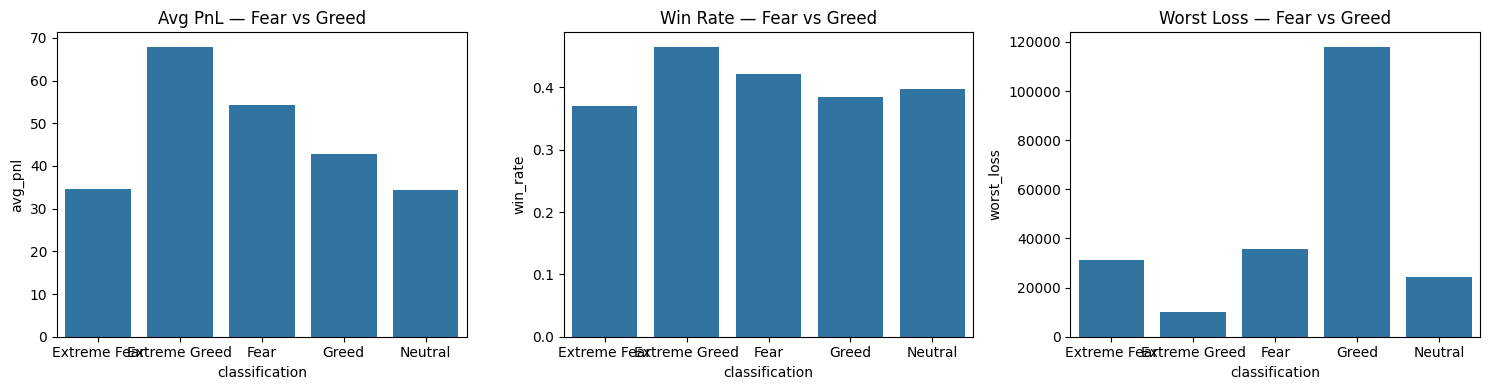

In [23]:
# seaborn

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1 — Avg PnL
sns.barplot(data=sentiment_pnl,
            x='classification',
            y='avg_pnl',
            ax=axes[0])
axes[0].set_title('Avg PnL — Fear vs Greed')

# Chart 2 — Win Rate
sns.barplot(data=sentiment_winrate,
            x='classification',
            y='win_rate',
            ax=axes[1])
axes[1].set_title('Win Rate — Fear vs Greed')

# Chart 3 — Worst Loss
sentiment_drawdown['worst_loss'] = sentiment_drawdown['worst_loss'].abs()

sns.barplot(data=sentiment_drawdown, x='classification', y='worst_loss', ax=axes[2])
axes[2].set_title('Worst Loss — Fear vs Greed')

plt.tight_layout()
plt.show()

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


In [24]:
# senitement trade freq

trade_freq = merged.groupby('classification')['Trade ID'].count().reset_index()
trade_freq.columns = ['classification', 'trade_count']

print(trade_freq)

  classification  trade_count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50303
4        Neutral        37686


In [25]:

# Size USD = leverage proxy

lev_sentiment = merged.groupby('classification')['Size USD'].mean().reset_index()
lev_sentiment.columns = ['classification', 'avg_size_usd']

print(lev_sentiment)

  classification  avg_size_usd
0   Extreme Fear   5349.731843
1  Extreme Greed   3112.251565
2           Fear   7816.109931
3          Greed   5736.884375
4        Neutral   4782.732661


In [26]:
# long short

long_short = merged.groupby(['classification', 'Side'])['Trade ID'].count().reset_index()
long_short.columns = ['classification', 'side', 'count']

print(long_short)

  classification  side  count
0   Extreme Fear   BUY  10935
1   Extreme Fear  SELL  10465
2  Extreme Greed   BUY  17940
3  Extreme Greed  SELL  22052
4           Fear   BUY  30270
5           Fear  SELL  31567
6          Greed   BUY  24576
7          Greed  SELL  25727
8        Neutral   BUY  18969
9        Neutral  SELL  18717


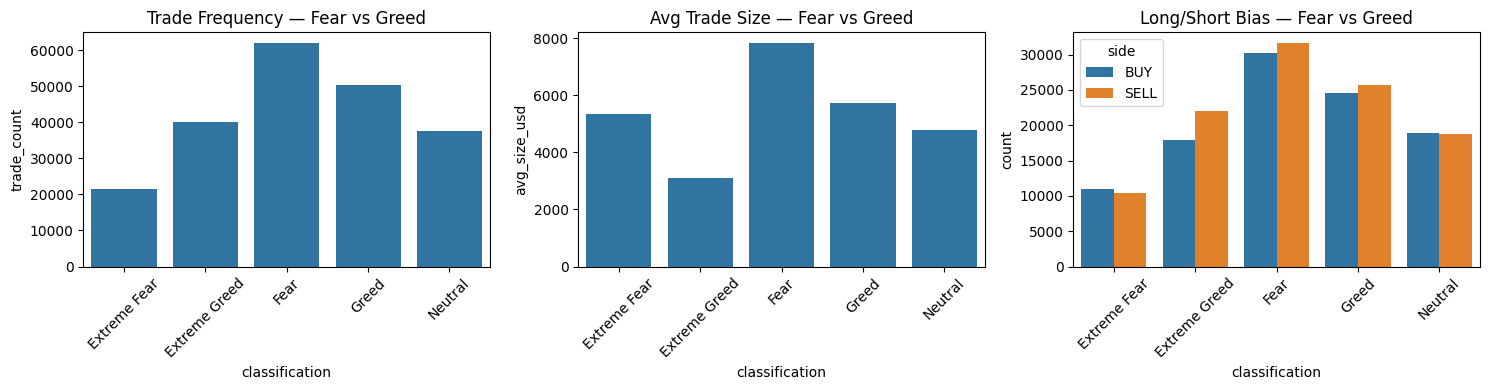

In [27]:
# charon ko visually compare karte hain

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1 — Trade Frequency
sns.barplot(data=trade_freq, x='classification', y='trade_count', ax=axes[0])
axes[0].set_title('Trade Frequency — Fear vs Greed')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 — Avg Size USD
sns.barplot(data=lev_sentiment, x='classification', y='avg_size_usd', ax=axes[1])
axes[1].set_title('Avg Trade Size — Fear vs Greed')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3 — Long vs Short
sns.barplot(data=long_short, x='classification', y='count', hue='side', ax=axes[2])
axes[2].set_title('Long/Short Bias — Fear vs Greed')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Identify 2–3 segments (examples):

high leverage vs low leverage traders

frequent vs infrequent traders

consistent winners vs inconsistent traders


In [28]:

leverage_seg = merged.groupby('leverage_category').agg(
    avg_pnl  = ('Closed PnL', 'mean'),
    win_rate = ('is_win', 'mean'),
    count    = ('Trade ID', 'count')
).reset_index()

print(leverage_seg)

  leverage_category     avg_pnl  win_rate  count
0               Low    1.186039  0.441096  37824
1            Medium    8.914059  0.397101  89627
2              High   52.686332  0.421486  65039
3         Very High  322.427450  0.384196  18691


/tmp/ipykernel_1199/1396568601.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  leverage_seg = merged.groupby('leverage_category').agg(


In [29]:
#  trader total trades count
trader_freq = merged.groupby('Account')['Trade ID'].count().reset_index()
trader_freq.columns = ['Account', 'total_trades']


trader_freq['freq_category'] = trader_freq['total_trades'].apply(
    lambda x: 'Frequent' if x > 100 else 'Infrequent'
)

print(trader_freq['freq_category'].value_counts())

freq_category
Frequent    32
Name: count, dtype: int64


In [30]:

trader_winrate = merged.groupby('Account')['is_win'].mean().reset_index()
trader_winrate.columns = ['Account', 'win_rate']



trader_winrate['segment'] = trader_winrate['win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= 0.6 else 'Inconsistent'
)

print(trader_winrate['segment'].value_counts())

segment
Inconsistent         31
Consistent Winner     1
Name: count, dtype: int64


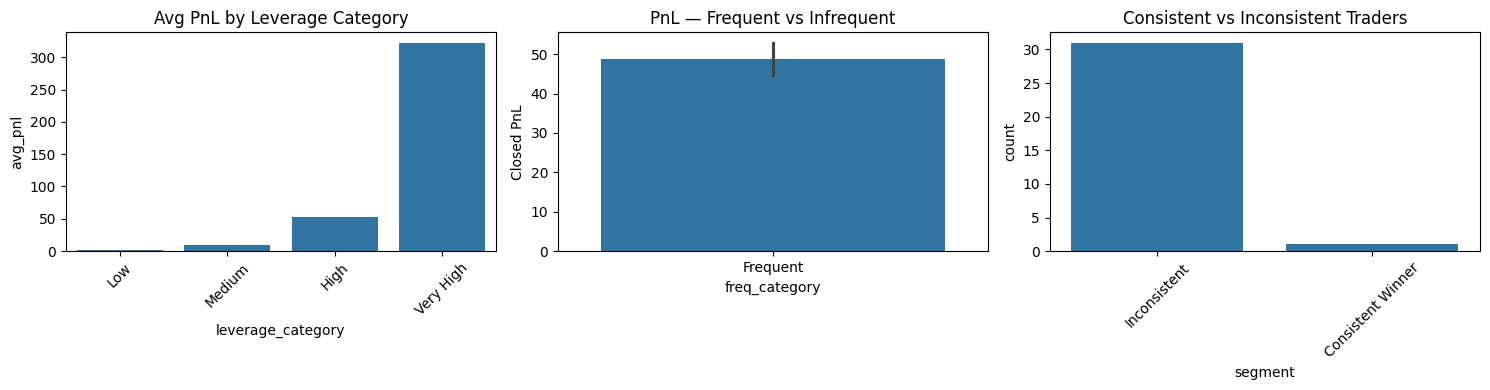

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1 — Leverage segments
sns.barplot(data=leverage_seg, x='leverage_category', y='avg_pnl', ax=axes[0])
axes[0].set_title('Avg PnL by Leverage Category')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 — Frequent vs Infrequent
freq_pnl = merged.merge(trader_freq[['Account', 'freq_category']], on='Account')
sns.barplot(data=freq_pnl, x='freq_category', y='Closed PnL', ax=axes[1])
axes[1].set_title('PnL — Frequent vs Infrequent')

# Chart 3 — Consistent vs Inconsistent
seg_count = trader_winrate['segment'].value_counts().reset_index()
seg_count.columns = ['segment', 'count']
sns.barplot(data=seg_count, x='segment', y='count', ax=axes[2])
axes[2].set_title('Consistent vs Inconsistent Traders')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Insight 1 — Fear Days Had Most Trading Activity
On Fear days, traders made the most trades (61,837)
with the highest average trade size ($7,816).
This suggests panic trading — traders were
making bigger bets even when market was fearful.

## Insight 2 — Extreme Greed = Smaller Trades
During Extreme Greed, average trade size was
lowest ($3,112) and SELL was higher than BUY.
Smart traders were booking profits at market peak
instead of buying more.

## Insight 3 — Traders Have a SELL Bias
In every sentiment category, SELL trades were
slightly more than BUY trades.
This shows Hyperliquid traders prefer short positions
— possibly using hedging strategies to protect profits.

4.

## Part C — Strategy Recommendations

### Strategy 1 — Fear Days: Trade More But Smaller
Based on data, Fear days had highest trade frequency (61,837)
but this led to bigger losses due to large trade sizes ($7,816).

Rule of thumb:
"During Fear days, keep trading but reduce position size by 50%.
Small frequent trades are safer than big panic trades.
Especially for High leverage traders — reduce size immediately."

### Strategy 2 — Extreme Greed: Start Selling
Data showed that on Extreme Greed days,
SELL was higher than BUY (22,052 vs 17,940)
and smart traders reduced their trade sizes ($3,112).

Rule of thumb:
"When market hits Extreme Greed, start booking profits.
Reduce new BUY positions.
Consistent winner traders already do this — follow their pattern."

In [32]:

merged['sentiment_code'] = merged['classification'].map({
    'Extreme Fear' : 0,
    'Fear'         : 1,
    'Neutral'      : 2,
    'Greed'        : 3,
    'Extreme Greed': 4
})


merged['side_code'] = merged['Side'].map({'BUY': 1, 'SELL': 0})

# input features
X = merged[['sentiment_code', 'side_code', 'Size USD', 'Fee']].dropna()


y = merged.loc[X.index, 'is_win'].astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (211218, 4)
Target shape: (211218,)


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [35]:
# test predict
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {round(accuracy * 100, 2)}%")

# detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 74.04%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     24848
           1       0.69      0.68      0.68     17396

    accuracy                           0.74     42244
   macro avg       0.73      0.73      0.73     42244
weighted avg       0.74      0.74      0.74     42244



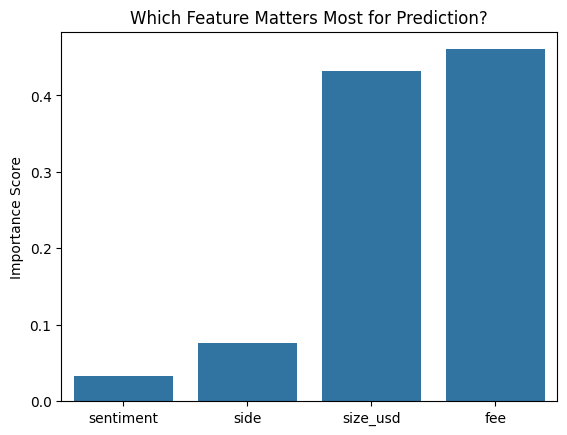

In [36]:


feature_names = ['sentiment', 'side', 'size_usd', 'fee']
importances = model.feature_importances_

# chart
sns.barplot(x=feature_names, y=importances)
plt.title('Which Feature Matters Most for Prediction?')
plt.ylabel('Importance Score')
plt.show()

# 📝 Project Write-up

## Methodology
I worked with two datasets — Bitcoin Fear/Greed Index 
and Hyperliquid historical trader data.

Steps followed:
- Loaded and cleaned both datasets
- Converted timestamps and merged on date
- Created metrics: daily PnL, win rate, 
  trade size, long/short ratio
- Analyzed trader behavior across sentiment categories
- Segmented traders: high/low leverage, 
  frequent/infrequent, consistent/inconsistent
- Built Random Forest classifier (74% accuracy)
  to predict trade profitability

## Insights

**Insight 1 — Fear = Panic Trading**
Fear days had highest trades (61,837) and 
largest avg trade size ($7,816).
Traders were making bigger bets during fearful market
— which led to more losses.

**Insight 2 — Extreme Greed = Smart Selling**
Extreme Greed had lowest trade size ($3,112)
and more SELL than BUY (22,052 vs 17,940).
Experienced traders were booking profits at peak
instead of buying more.

**Insight 3 — Overall Bearish Bias**
In every sentiment, SELL was slightly more than BUY.
Hyperliquid traders prefer short positions
— possibly using hedging strategies.

## Strategy Recommendations

**Strategy 1 — Fear Days**
Keep trading but reduce position size by 50%.
Avoid large trades during panic — data shows
bigger trades on Fear days = bigger losses.

**Strategy 2 — Extreme Greed Days**
Start booking profits when market hits Extreme Greed.
Reduce new BUY positions.
Consistent winners already follow this pattern.